In [1]:
import pandas as pd
import numpy as np
import cdflib
import matplotlib.pyplot as plt


## Reading the data

In [1]:
fp_mms1_moms="C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf"

In [4]:
fp_mms1_dist = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf"
#fp_mms1_moms = 'data/mms1/fpi/brst/l2/des-moms/2024/01/01/mms1_fpi_brst_l2_des-moms_20240101131913_v3.4.0.cdf'
#fp_mms4_dist = 'data/mms4/fpi/brst/l2/des-dist/2024/01/01/mms4_fpi_brst_l2_des-dist_20240101131913_v3.4.0.cdf'

with cdflib.CDF(fp_mms1_dist) as cdf_file:
    # Get the global attributes
    global_attributes = cdf_file.globalattsget()
    print("Attributes:")
    for attr, value in global_attributes.items():
        print(f"{attr}: {value}")

    # Get the variable names using cdf_info().rVariables and zVariables
    cdf_info = cdf_file.cdf_info()
    variables = cdf_info.rVariables + cdf_info.zVariables
    print("\nVariables:")
    for var in variables:
        print(var)

    # Get the attributes of each variable
    print("\nVariable Attributes:")
    for var in variables:
        var_attrs = cdf_file.varattsget(var)
        print(f"\nAttributes for {var}:")
        for attr, value in var_attrs.items():
            print(f"{attr}: {value}")

    # Get the data of each variable
    print("\nVariable Data Sizes:")
    for var in variables:
        data = cdf_file.varget(var)
        if type(data) == np.ndarray:
            print(f"{var}: {data.shape}")
        else:
            print(f"{var}: {data}")

Attributes:
Project: ['STP>Solar-Terrestrial Physics']
Source_name: ['MMS1>MMS Satellite Number 1']
Discipline: ['Space Physics>Magnetospheric Science']
Data_type: ['brst_l2_des-dist']
Descriptor: ['DES>Dual Electron Spectrometers']
File_naming_convention: ['source_descriptor_datatype_yyyyMMddHHmmss']
Data_version: ['3.4.0']
PI_name: ['J. Burch, B. Giles']
PI_affiliation: ['SwRI, GSFC']
TEXT: ['FPI usually operates in Fast Survey Mode in the MMS Region Of Interest (ROI) for the current Mission Phase.  Data are taken at burst (30/150 ms for DES/DIS) resolution in this mode.  Data are also made available at survey (4.5 s, etc) resolution; these form a separate product from this.  Per mission design, not all burst-resolution data are downlinked.  This product contains phase-space distribution maps of those burst-resolution data selected for downlink.  In particular, the (highest possible quality at the time of release) corrected/converted "Burst SkyMap" distributions are reported with tim

mms1_des_dist_brst: (4333, 32, 16, 32)
mms1_des_disterr_brst: (4333, 32, 16, 32)
mms1_des_avgf1counts_brst: (4333, 32)
mms1_des_steptimeoffsets_brst: (4333, 32, 16, 32)
mms1_des_sector_despinp_brst: (4333,)
mms1_des_sector_label_brst: (1, 32)
mms1_des_pixel_label_brst: (1, 16)
mms1_des_energy_label_brst: (1, 32)
mms1_des_theta_brst: (16,)
mms1_des_theta_delta_brst: (16,)
mms1_des_energy_brst: (4333, 32)
mms1_des_energy_delta_brst: (4333, 32)


In [7]:
dist_data = cdf_file.varget('mms1_des_dist_brst')
phi_data = cdf_file.varget('mms1_des_phi_brst')
theta_data = cdf_file.varget('mms1_des_theta_brst')
energy_data = cdf_file.varget('mms1_des_energy_brst')
epoch_data = cdf_file.varget('Epoch')

In [8]:
dist_data.shape, phi_data.shape, theta_data.shape, energy_data.shape, epoch_data.shape

((4333, 32, 16, 32), (4333, 32), (16,), (4333, 32), (4333,))

Number density: As described earlier.
Bulk velocity: Weighted by the phase space density and integrated over energy, azimuth, and elevation.
Pressure tensor: Involves the second moment of the velocity distribution.
Entropy: Using specific integrals, possibly linked with entropy flux.

In [9]:
time_index = 0 

# Extract the data cube for this time step
data_cube = dist_data[time_index]  # Shape: (32, 16, 32)

In [10]:
# Check for missing values (NaNs)
num_nans = np.isnan(data_cube).sum()
print(f"Number of NaNs in data cube at time {time_index}: {num_nans}")

Number of NaNs in data cube at time 0: 0


In [13]:
data_cube[0].shape

(16, 32)

In [24]:
# for energy_index in range(0,10): # [0,32]
#     # Extract a 2D slice at this energy level
#     slice_data = data_cube[energy_index]  # Shape: (16, 32)

#     # Plot the slice
#     plt.imshow(slice_data, aspect='auto', origin='lower', cmap='viridis')
#     plt.colorbar(label='Phase Space Density')
#     plt.xlabel('Phi Index')
#     plt.ylabel('Theta Index')
#     plt.title(f'Data Slice at Time {time_index}, Energy Index {energy_index}')
#     plt.show()

## Plotting slices of data

In [21]:
# Specify the energy index (from 0 to 31)
energy_index = 31  # Change as needed

# Extract the 2D slice at this energy level
# data_cube has shape (phi, theta, energy)
slice_data = data_cube[:, :, energy_index]  # Shape: (phi, theta)


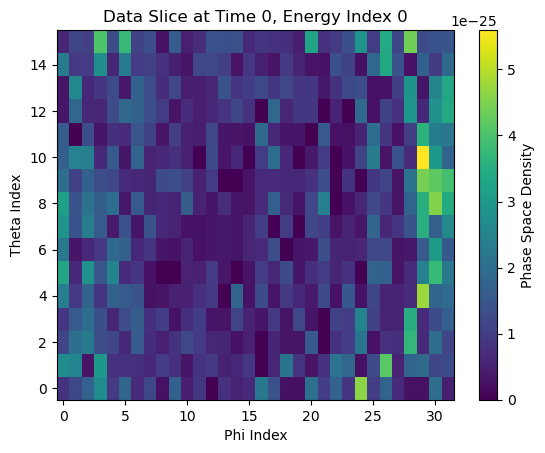

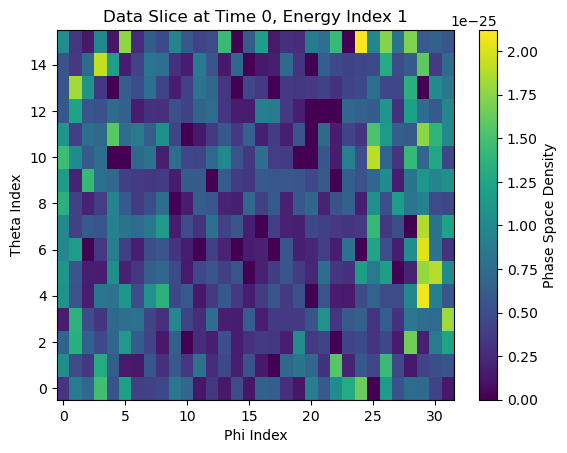

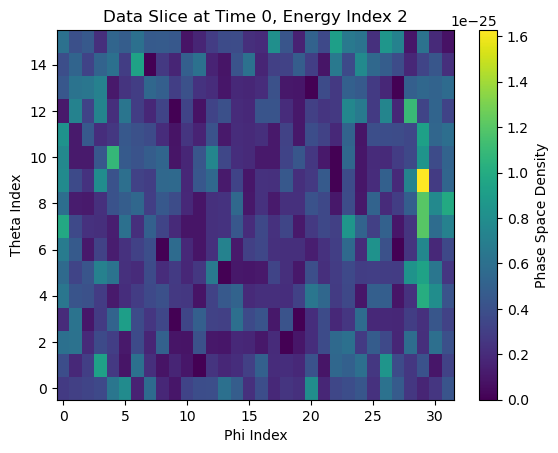

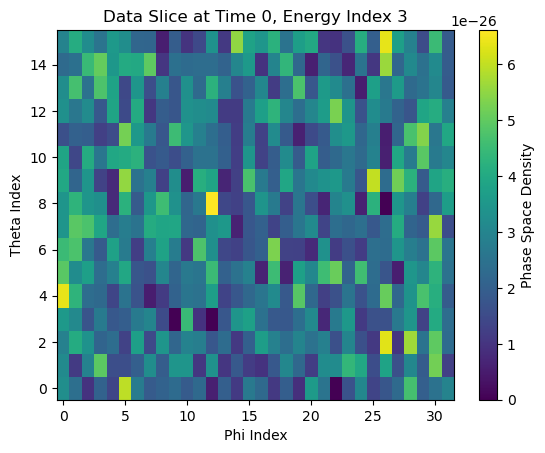

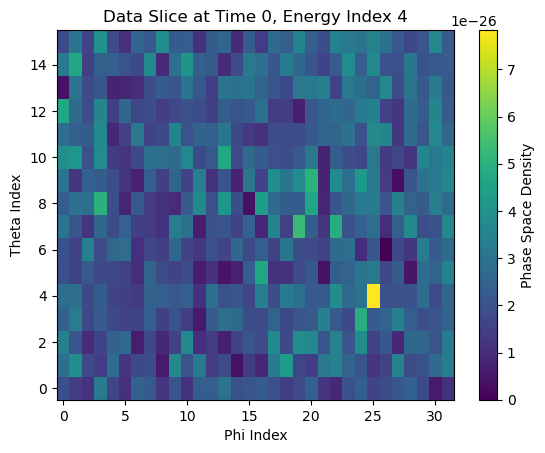

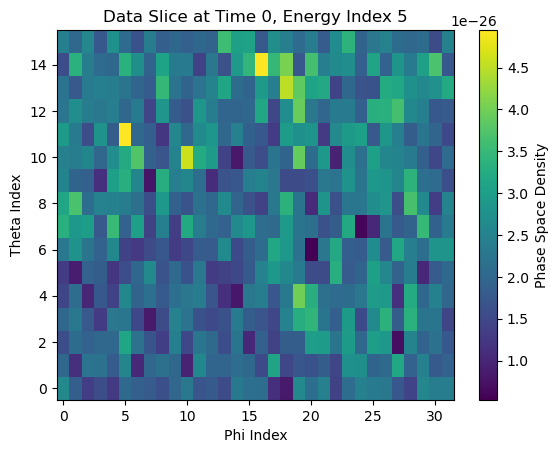

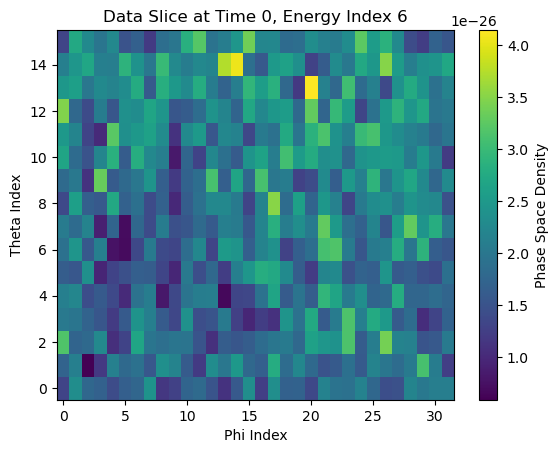

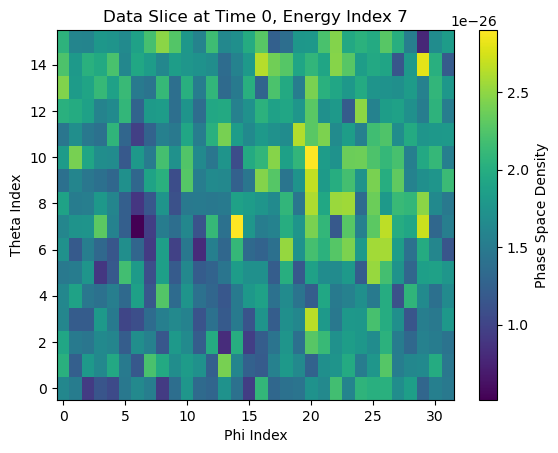

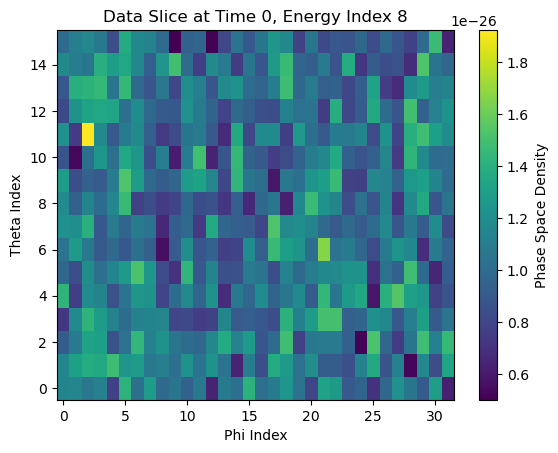

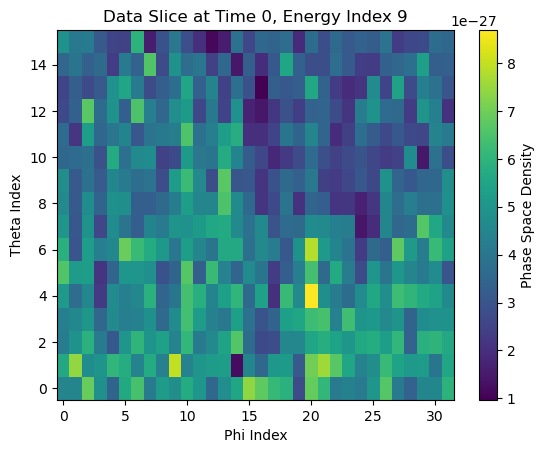

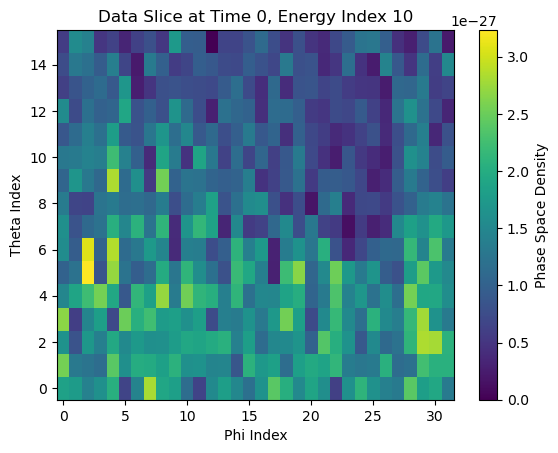

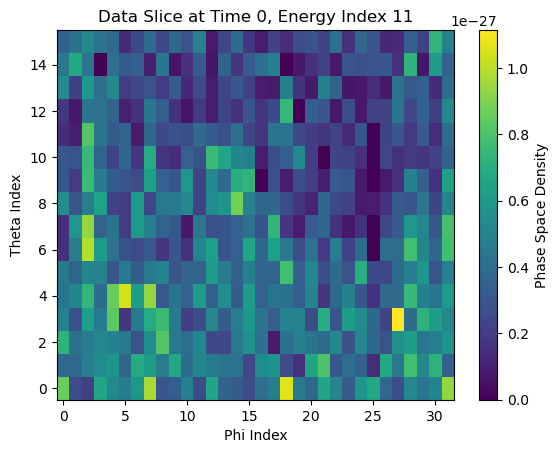

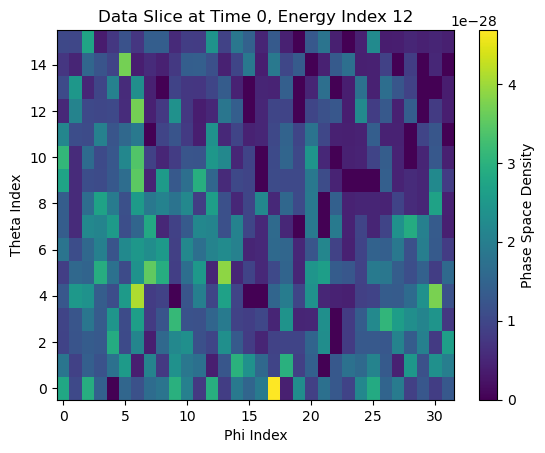

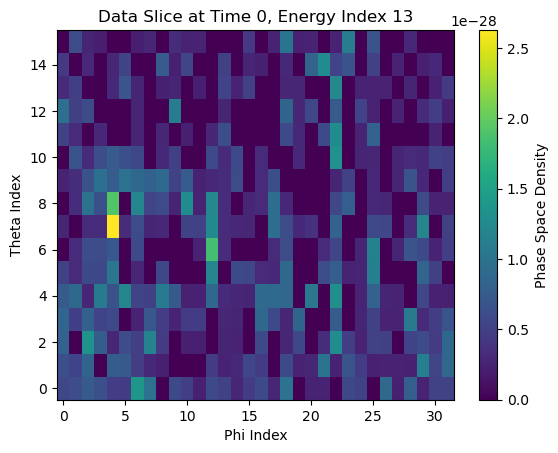

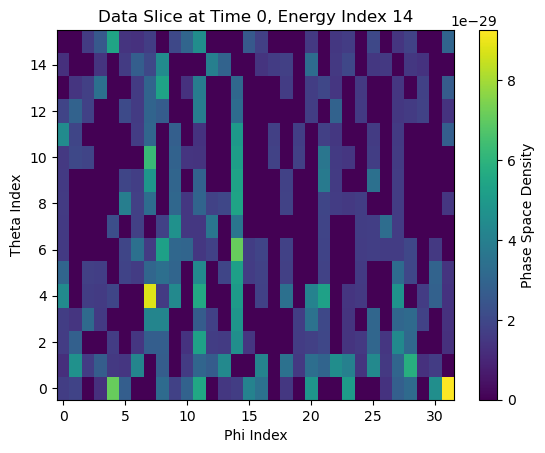

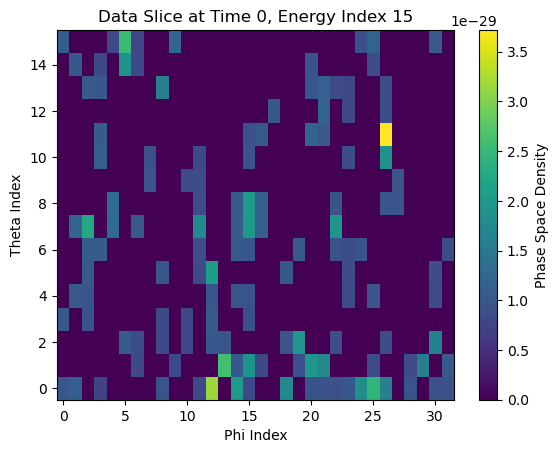

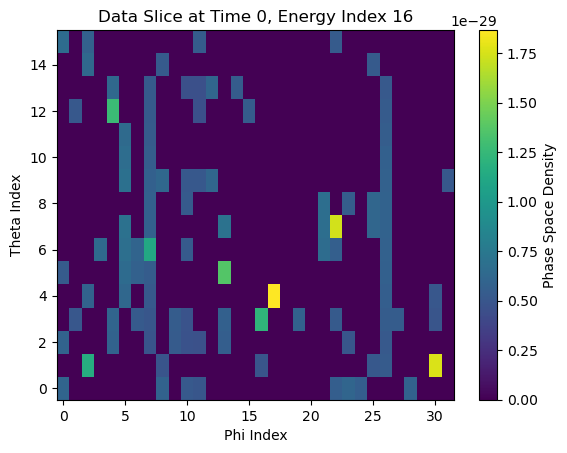

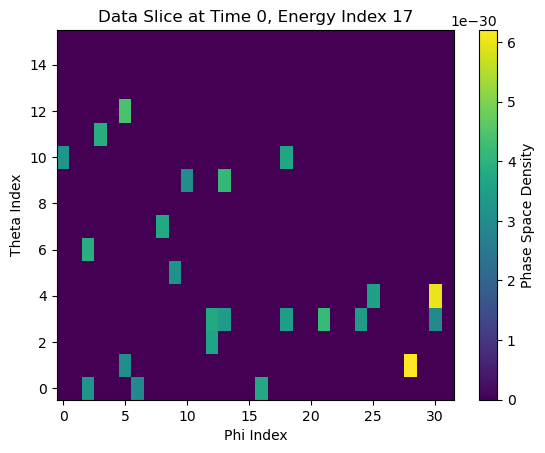

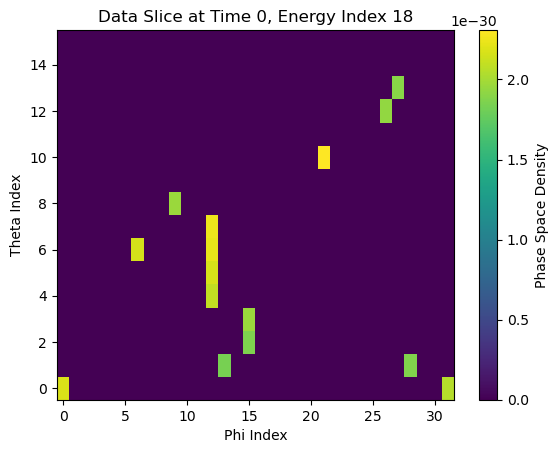

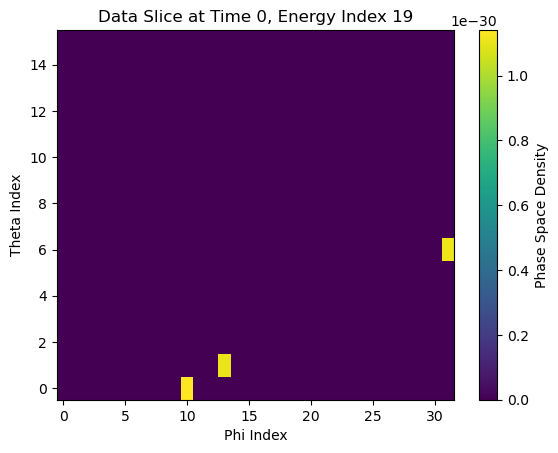

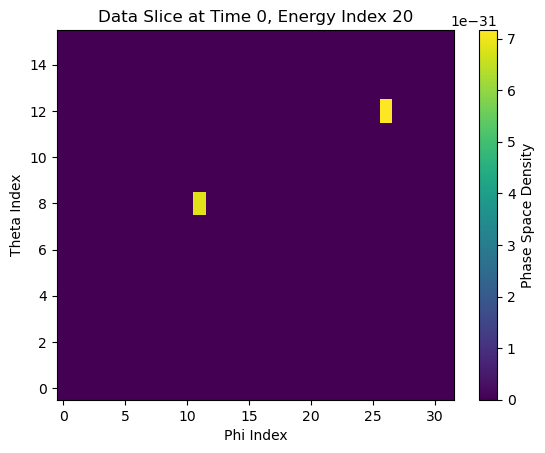

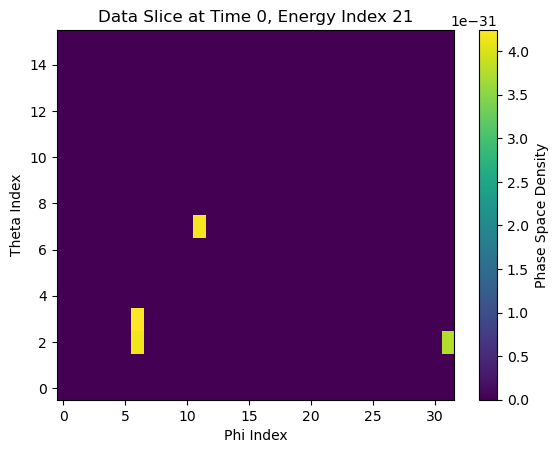

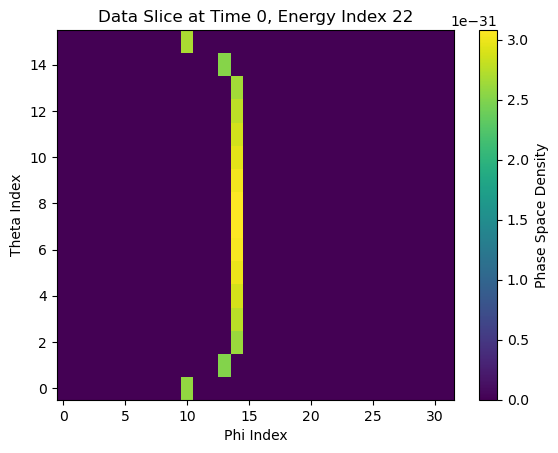

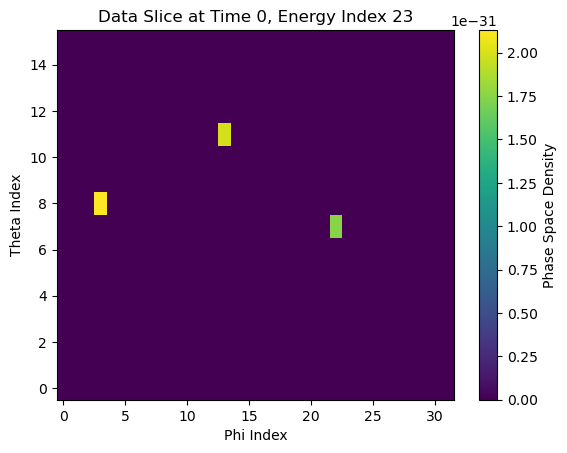

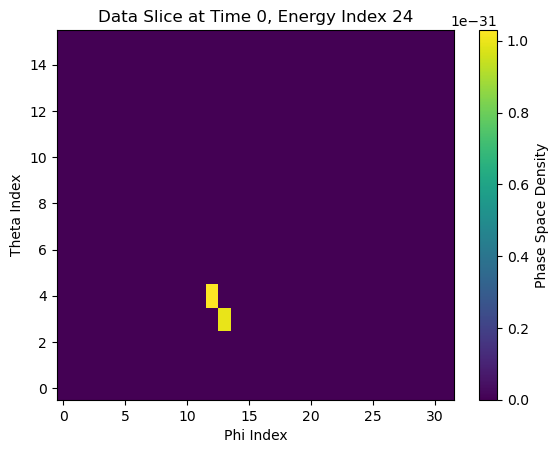

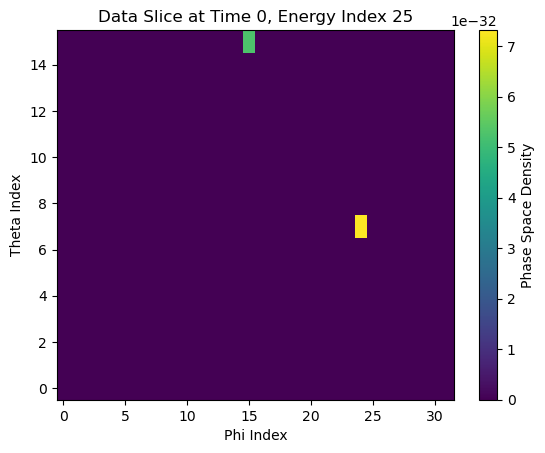

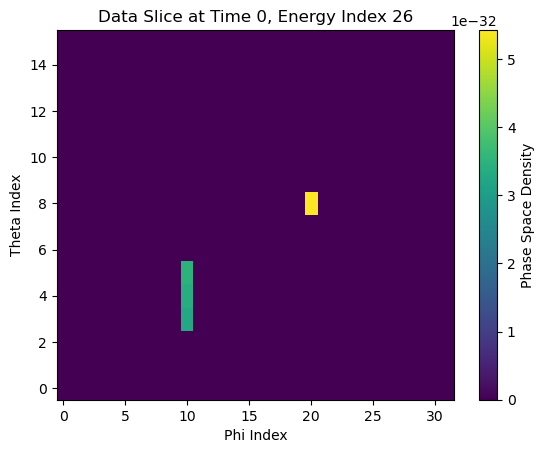

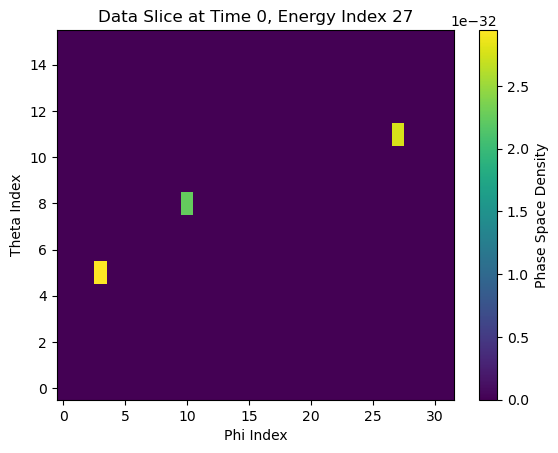

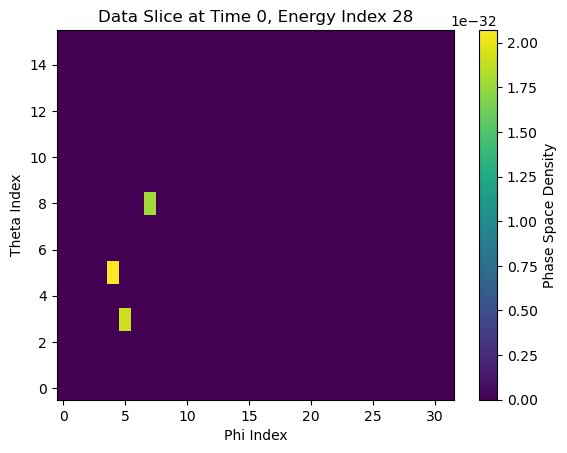

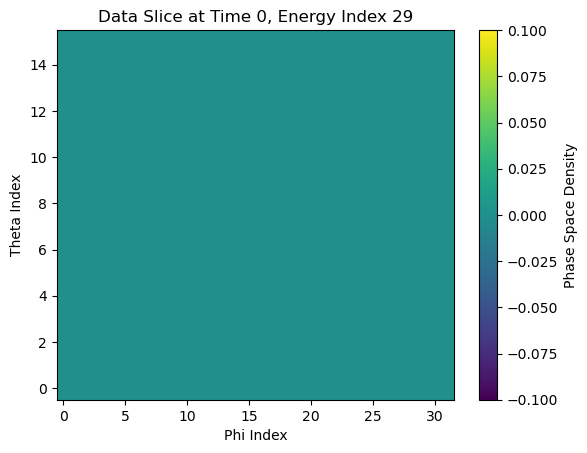

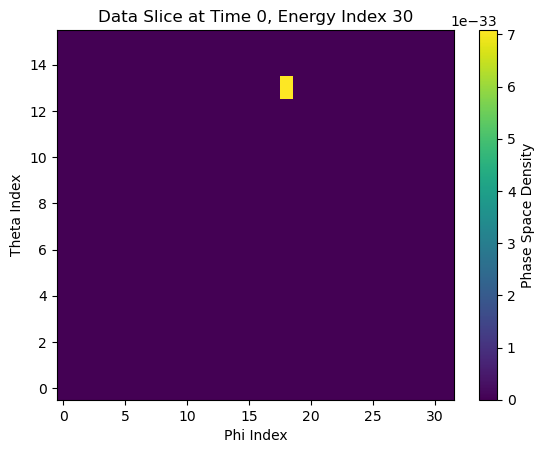

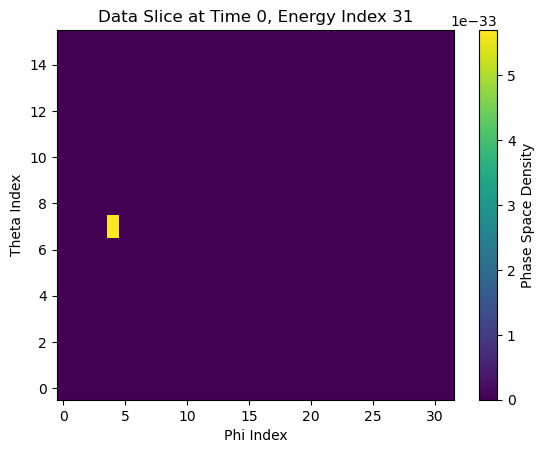

In [23]:
# Loop over energy indices
for energy_index in range(32):  # Energy indices from 0 to 31
    # Extract the 2D slice at this energy level
    # data_cube has shape (phi, theta, energy)
    slice_data = data_cube[:, :, energy_index]  # Shape: (phi, theta)

    # Transpose slice_data for correct orientation in the plot
    slice_data = slice_data.T  # Now shape is (theta, phi)

    plt.imshow(slice_data, aspect='auto', origin='lower', cmap='viridis')
    plt.colorbar(label='Phase Space Density')
    plt.xlabel('Phi Index')    # Phi varies along the x-axis
    plt.ylabel('Theta Index')  # Theta varies along the y-axis
    plt.title(f'Data Slice at Time {time_index}, Energy Index {energy_index}')
    plt.show()



* Double check the axis (angle and energy)

In [25]:
# we have no missing data
# Replace NaNs with zeros (or any suitable value)
num_nans = np.isnan(dist_data).sum()
print(f"Total number of NaNs in dist_data: {num_nans}")

dist_data_filled = dist_data.copy()

Total number of NaNs in dist_data: 0


In [26]:
# Normalize the data to the range [0, 1]
data_min = dist_data.min()
data_max = dist_data.max()
dist_data_normalized = (dist_data - data_min) / (data_max - data_min)


# Verify the normalization
print(f"Data min after normalization: {dist_data_normalized.min()}")
print(f"Data max after normalization: {dist_data_normalized.max()}")

Data min after normalization: 0.0
Data max after normalization: 1.0


In [29]:
dist_data_normalized.shape

(4333, 32, 16, 32)

In [30]:
dist_data_normalized = dist_data_normalized[..., np.newaxis]
print(f"New shape of dist_data_normalized: {dist_data_normalized.shape}")


New shape of dist_data_normalized: (4333, 32, 16, 32, 1)


In [31]:
from sklearn.model_selection import train_test_split

# First, split the data into training+validation and test sets (90% and 10%)
X_temp, X_test = train_test_split(
    dist_data_normalized, test_size=0.10, random_state=42
)

# Next, split the X_temp into training and validation sets (approx. 80% and 10%)
X_train, X_val = train_test_split(
    X_temp, test_size=0.1111, random_state=42
)
# Note: 0.1111 * 90% ≈ 10% of the original data

# Print the shapes to verify the splits
print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")


Training set shape: (3465, 32, 16, 32, 1)
Validation set shape: (434, 32, 16, 32, 1)
Test set shape: (434, 32, 16, 32, 1)


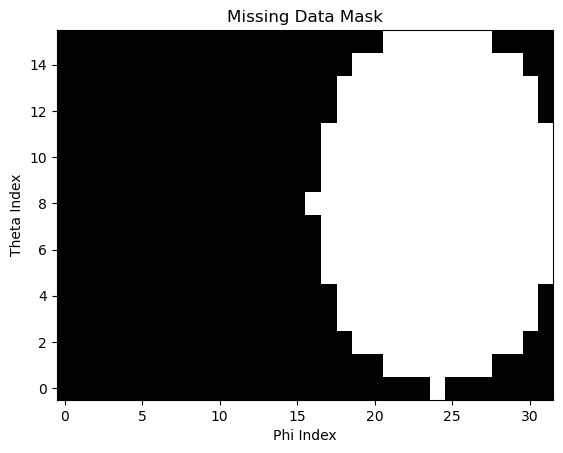

In [32]:
import numpy as np

# Dimensions
theta_size = 16  # Theta dimension size
phi_size = 32    # Phi dimension size

# Create coordinate grids
phi_indices = np.arange(phi_size)
theta_indices = np.arange(theta_size)
phi_grid, theta_grid = np.meshgrid(phi_indices, theta_indices)

# Define the center and radius of the missing circle
center_phi = phi_size // 2 + 8  # Adjust as needed to position the circle on the right
center_theta = theta_size // 2
radius = min(phi_size, theta_size) // 2  # Adjust radius as needed

# Create the mask
mask = np.zeros((theta_size, phi_size), dtype=bool)
distance_squared = (phi_grid - center_phi) ** 2 + (theta_grid - center_theta) ** 2
mask[distance_squared <= radius ** 2] = True  # True where data is missing

# Visualize the mask
import matplotlib.pyplot as plt

plt.imshow(mask, aspect='auto', origin='lower', cmap='gray')
plt.title('Missing Data Mask')
plt.xlabel('Phi Index')
plt.ylabel('Theta Index')
plt.show()


In [33]:
# Total number of time steps
num_samples = dist_data_normalized.shape[0]

# Calculate split index for 80% training data
split_index = int(num_samples * 0.8)

# Split the data
X_train = dist_data_normalized[:split_index]
X_test = dist_data_normalized[split_index:]

# Verify the shapes
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")


Training set shape: (3466, 32, 16, 32, 1)
Test set shape: (867, 32, 16, 32, 1)


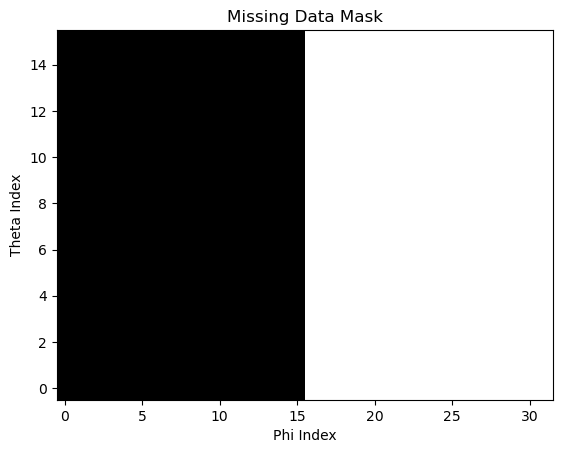

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Dimensions of the skymap (theta and phi)
theta_size = 16
phi_size = 32

# Create the mask
mask = np.zeros((theta_size, phi_size), dtype=bool)
mask[:, phi_size // 2:] = True  # Set True (missing) for phi indices in the right half

# Visualize the mask
plt.imshow(mask, aspect='auto', origin='lower', cmap='gray')
plt.title('Missing Data Mask')
plt.xlabel('Phi Index')
plt.ylabel('Theta Index')
plt.show()


In [37]:
# Copy the test set to avoid modifying the original data
X_test_missing = np.copy(X_test)

# Apply the mask to each sample and energy level
for i in range(X_test_missing.shape[0]):  # Loop over samples
    for energy_index in range(X_test_missing.shape[3]):  # Loop over energy levels (axis 3)
        # Extract the slice for this energy level
        slice_data = X_test_missing[i, :, :, energy_index, 0]  # Shape: (phi_size, theta_size)
        
        # Transpose slice_data to shape (theta_size, phi_size) to match mask dimensions
        slice_data = slice_data.T  # Now shape is (theta_size, phi_size)
        
        # Apply the mask
        slice_data[mask] = 0.0  # Set missing data to 0.0
        
        # Transpose back to original shape
        slice_data = slice_data.T  # Back to shape (phi_size, theta_size)
        
        # Assign the modified slice back to the data
        X_test_missing[i, :, :, energy_index, 0] = slice_data



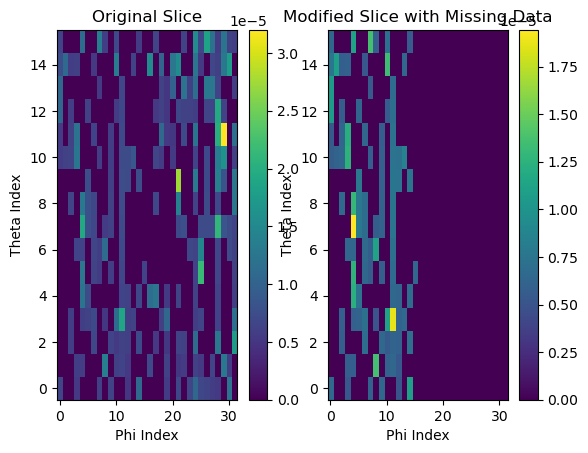

In [38]:
# Visualize a sample from the modified test set
sample_index = 0  # Change as needed
energy_index = 15  # Midpoint energy level

# Extract the original and modified slices
original_slice = X_test[sample_index, :, :, energy_index, 0]
modified_slice = X_test_missing[sample_index, :, :, energy_index, 0]

# Transpose for correct orientation
original_slice = original_slice.T  # Shape: (theta_size, phi_size)
modified_slice = modified_slice.T  # Shape: (theta_size, phi_size)

# Plot the original slice
plt.subplot(1, 2, 1)
plt.imshow(original_slice, aspect='auto', origin='lower', cmap='viridis')
plt.title('Original Slice')
plt.xlabel('Phi Index')
plt.ylabel('Theta Index')
plt.colorbar()

# Plot the modified slice
plt.subplot(1, 2, 2)
plt.imshow(modified_slice, aspect='auto', origin='lower', cmap='viridis')
plt.title('Modified Slice with Missing Data')
plt.xlabel('Phi Index')
plt.ylabel('Theta Index')
plt.colorbar()

plt.show()


In [39]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, UpSampling3D
from tensorflow.keras.models import Model

# Define the input shape based on your training data
input_shape = X_train.shape[1:]  # Should be (32, 16, 32, 1)

# Build the autoencoder model
# Encoder
input_img = Input(shape=input_shape)
x = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling3D((2, 2, 2), padding='same')(x)
x = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling3D((2, 2, 2), padding='same')(x)

# Decoder
x = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(encoded)
x = UpSampling3D((2, 2, 2))(x)
x = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(x)
x = UpSampling3D((2, 2, 2))(x)
decoded = Conv3D(1, (3, 3, 3), activation='sigmoid', padding='same')(x)

# Create the autoencoder model
autoencoder = Model(inputs=input_img, outputs=decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Display the model summary
autoencoder.summary()





Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 16, 32, 1)]   0         
                                                                 
 conv3d (Conv3D)             (None, 32, 16, 32, 32)    896       
                                                                 
 max_pooling3d (MaxPooling3  (None, 16, 8, 16, 32)     0         
 D)                                                              
                                                                 
 conv3d_1 (Conv3D)           (None, 16, 8, 16, 64)     55360     
                                                                 
 max_pooling3d_1 (MaxPoolin  (None, 8, 4, 8, 64)       0         
 g3D)                                                            
                                                                 
 conv3d_2 (Conv3D)           (None, 8, 4, 8, 64)       110

In [32]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, UpSampling3D
from tensorflow.keras.models import Model

# Define the input shape based on your data
input_shape = X_train_noisy.shape[1:]  # Should be (32, 16, 32, 1)

# Encoder
input_img = Input(shape=input_shape)
x = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling3D((2, 2, 2), padding='same')(x)
x = Conv3D(16, (3, 3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling3D((2, 2, 2), padding='same')(x)

# Decoder
x = Conv3D(16, (3, 3, 3), activation='relu', padding='same')(encoded)
x = UpSampling3D((2, 2, 2))(x)
x = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(x)
x = UpSampling3D((2, 2, 2))(x)
decoded = Conv3D(1, (3, 3, 3), activation='sigmoid', padding='same')(x)

# Autoencoder Model
autoencoder = Model(inputs=input_img, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error') # Custom loss function comparing moments, 20 sec peak in fft

# Display the model summary
autoencoder.summary()





Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 16, 32, 1)]   0         
                                                                 
 conv3d (Conv3D)             (None, 32, 16, 32, 32)    896       
                                                                 
 max_pooling3d (MaxPooling3  (None, 16, 8, 16, 32)     0         
 D)                                                              
                                                                 
 conv3d_1 (Conv3D)           (None, 16, 8, 16, 16)     13840     
                                                                 
 max_pooling3d_1 (MaxPoolin  (None, 8, 4, 8, 16)       0         
 g3D)                                                            
                                                                 
 conv3d_2 (Conv3D)           (None, 8, 4, 8, 16)       692

In [40]:
# Define the number of epochs and batch size
epochs = 20          # You can adjust this number
batch_size = 16      # Adjust based on your system's memory capacity

# Since we have time series data, we'll use the last 10% of X_train as validation data
# Calculate the split index for validation data
val_split_index = int(len(X_train) * 0.9)

# Split X_train into training and validation sets
X_train_train = X_train[:val_split_index]
X_train_val = X_train[val_split_index:]

# Train the autoencoder
history = autoencoder.fit(
    X_train_train, X_train_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=False,  # For time series data, we should not shuffle
    validation_data=(X_train_val, X_train_val)
)


Epoch 1/20

195/195 [==============================] - 34s 169ms/step - loss: 0.0056 - val_loss: 4.9507e-04
Epoch 2/20
195/195 [==============================] - 34s 175ms/step - loss: 5.0903e-04 - val_loss: 4.9507e-04
Epoch 3/20
195/195 [==============================] - 33s 168ms/step - loss: 5.0903e-04 - val_loss: 4.9507e-04
Epoch 4/20
195/195 [==============================] - 33s 171ms/step - loss: 5.0903e-04 - val_loss: 4.9507e-04
Epoch 5/20
195/195 [==============================] - 36s 184ms/step - loss: 5.0903e-04 - val_loss: 4.9507e-04
Epoch 6/20
195/195 [==============================] - 44s 228ms/step - loss: 5.0903e-04 - val_loss: 4.9507e-04
Epoch 7/20
195/195 [==============================] - 45s 233ms/step - loss: 5.0903e-04 - val_loss: 4.9507e-04
Epoch 8/20
195/195 [==============================] - 45s 228ms/step - loss: 5.0903e-04 - val_loss: 4.9507e-04
Epoch 9/20
195/195 [==============================] - 42s 213ms/step - loss: 5.0903e-04 - val_loss: 4.9507e-04
Epoc

In [33]:
# Train the autoencoder with verbose output
history = autoencoder.fit(
    X_train_noisy, X_train,
    epochs=20,              # Adjust the number of epochs as needed
    batch_size=16,          # Adjust based on your system's memory capacity
    shuffle=True,
    validation_data=(X_val, X_val),
    verbose=1               # Set verbose=1 for progress bar (default)
)


Epoch 1/20

234/234 [==============================] - 33s 135ms/step - loss: 0.0099 - val_loss: 5.2138e-04
Epoch 2/20
234/234 [==============================] - 31s 133ms/step - loss: 5.3294e-04 - val_loss: 5.2137e-04
Epoch 3/20
234/234 [==============================] - 32s 136ms/step - loss: 5.3292e-04 - val_loss: 5.2135e-04
Epoch 4/20
234/234 [==============================] - 32s 135ms/step - loss: 5.3290e-04 - val_loss: 5.2133e-04
Epoch 5/20
234/234 [==============================] - 31s 134ms/step - loss: 5.3288e-04 - val_loss: 5.2130e-04
Epoch 6/20
234/234 [==============================] - 31s 134ms/step - loss: 5.3284e-04 - val_loss: 5.2127e-04
Epoch 7/20
234/234 [==============================] - 31s 134ms/step - loss: 5.3278e-04 - val_loss: 5.2119e-04
Epoch 8/20
234/234 [==============================] - 31s 133ms/step - loss: 5.3240e-04 - val_loss: 5.1956e-04
Epoch 9/20
234/234 [==============================] - 31s 134ms/step - loss: 5.2391e-04 - val_loss: 5.2137e-04
Epoc

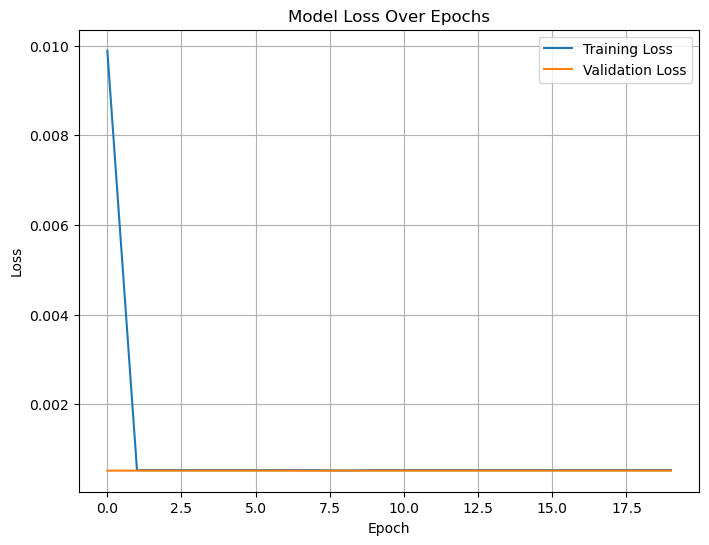

In [34]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


In [35]:
# Calculate the percentage of zeros in X_train_noisy
total_elements = np.product(X_train_noisy.shape)
num_zeros = np.sum(X_train_noisy == 0)
zero_percentage = (num_zeros / total_elements) * 100
print(f"Percentage of zeros in X_train_noisy: {zero_percentage:.2f}%")

# Compare with X_train to see if zeros correspond to missing data
difference = X_train_noisy - X_train
num_differences = np.sum(difference != 0)
difference_percentage = (num_differences / total_elements) * 100
print(f"Percentage of differing elements between X_train_noisy and X_train: {difference_percentage:.2f}%")


Percentage of zeros in X_train_noisy: 35.18%
Percentage of differing elements between X_train_noisy and X_train: 16.20%


In [36]:
# Flatten the arrays for comparison
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

# Check for common samples
common_samples = np.intersect1d(X_train_flat, X_val_flat)
print(f"Number of common samples between training and validation sets: {len(common_samples)}")


Number of common samples between training and validation sets: 412580


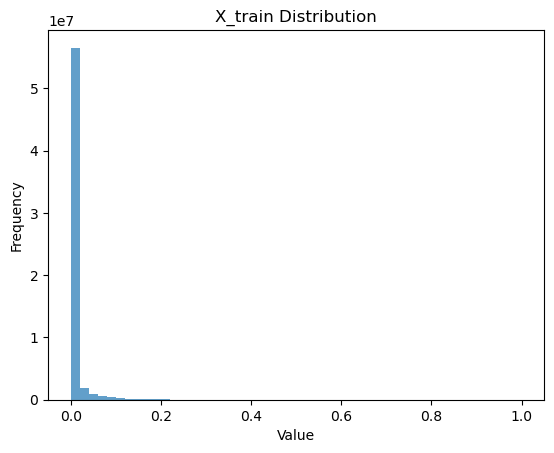

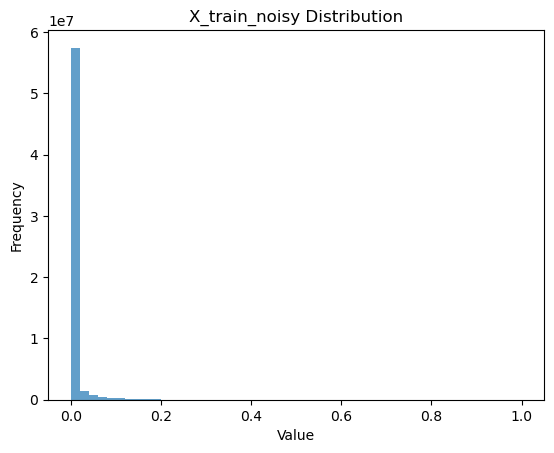

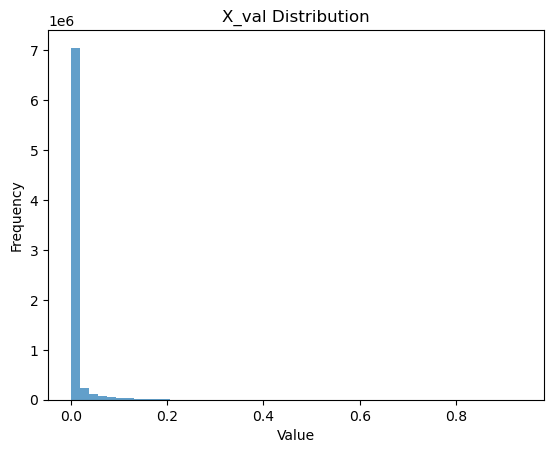

In [37]:
import matplotlib.pyplot as plt

# Function to plot histograms
def plot_histogram(data, title):
    plt.hist(data.flatten(), bins=50, alpha=0.7)
    plt.title(title)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()

# Plot histograms
plot_histogram(X_train, 'X_train Distribution')
plot_histogram(X_train_noisy, 'X_train_noisy Distribution')
plot_histogram(X_val, 'X_val Distribution')


1/1 [==============================] - 0s 132ms/step


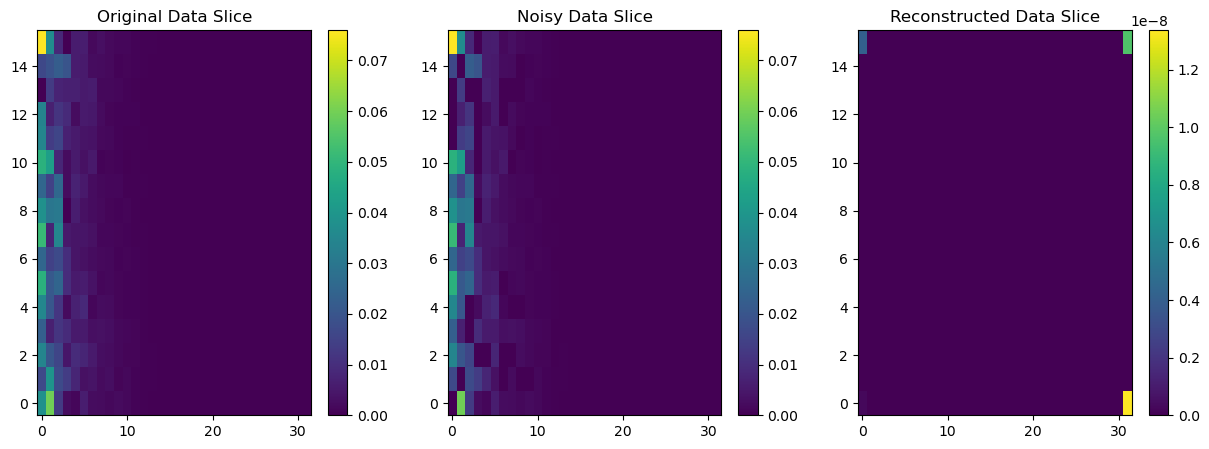

In [38]:
# Select a sample index
sample_index = 0  # Change as needed

# Extract the sample data
original_sample = X_train[sample_index]
noisy_sample = X_train_noisy[sample_index]

# Use the model to reconstruct the noisy sample
reconstructed_sample = autoencoder.predict(np.expand_dims(noisy_sample, axis=0))[0]

# Remove the channel dimension
original_cube = original_sample[..., 0]
noisy_cube = noisy_sample[..., 0]
reconstructed_cube = reconstructed_sample[..., 0]

# Choose an energy index to visualize
energy_index = 15  # Midpoint of the energy dimension

# Plot the slices
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_cube[energy_index], aspect='auto', origin='lower', cmap='viridis')
plt.title('Original Data Slice')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(noisy_cube[energy_index], aspect='auto', origin='lower', cmap='viridis')
plt.title('Noisy Data Slice')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(reconstructed_cube[energy_index], aspect='auto', origin='lower', cmap='viridis')
plt.title('Reconstructed Data Slice')
plt.colorbar()

plt.show()


In [39]:
# Evaluate on the test set
test_loss = autoencoder.evaluate(X_test, X_test, verbose=1)
print(f'Test loss: {test_loss}')


15/15 [==============================] - 1s 58ms/step - loss: 5.4754e-04
Test loss: 0.000547543226275593


In [40]:
data_variance = np.var(X_train)
print(f'Data variance: {data_variance}')


Data variance: 0.000491861836053431


In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Use the autoencoder to reconstruct the test data
X_test_pred = autoencoder.predict(X_test)

# Flatten the arrays for metric calculations
X_test_flat = X_test.reshape(len(X_test), -1)
X_test_pred_flat = X_test_pred.reshape(len(X_test_pred), -1)

# Compute Mean Squared Error
mse = mean_squared_error(X_test_flat, X_test_pred_flat)
print(f"Mean Squared Error on Test Set: {mse}")

# Compute Mean Absolute Error
mae = mean_absolute_error(X_test_flat, X_test_pred_flat)
print(f"Mean Absolute Error on Test Set: {mae}")

# Compute R-squared
r2 = r2_score(X_test_flat, X_test_pred_flat)
print(f"R-squared on Test Set: {r2}")


15/15 [==============================] - 1s 60ms/step
Mean Squared Error on Test Set: 0.0005475431680679321
Mean Absolute Error on Test Set: 0.0065156808122992516
R-squared on Test Set: -2935974233.8674517


In [42]:
# Compute SS_res and SS_tot
SS_res = np.sum((X_test_flat - X_test_pred_flat) ** 2)
SS_tot = np.sum((X_test_flat - np.mean(X_test_flat)) ** 2)
print(f'SS_res: {SS_res}')
print(f'SS_tot: {SS_tot}')


SS_res: 4189.42919921875
SS_tot: 3865.020751953125


In [44]:
variance_predicted = np.var(X_test_pred_flat)
print(f'Variance of predicted test data: {variance_predicted}')


Variance of predicted test data: 3.933694259217191e-09


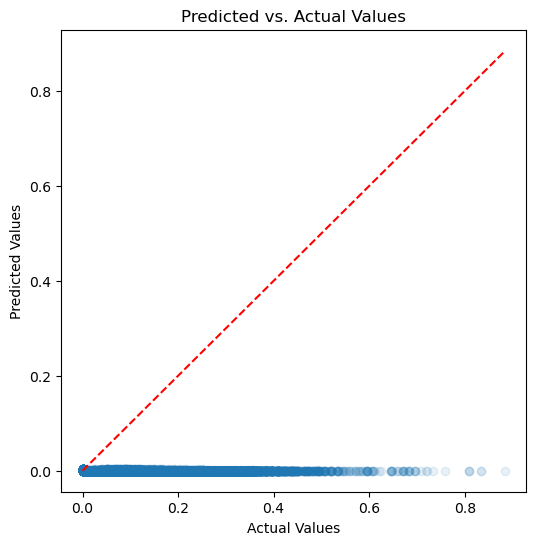

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(X_test_flat, X_test_pred_flat, alpha=0.1)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs. Actual Values')
plt.plot([X_test_flat.min(), X_test_flat.max()], [X_test_flat.min(), X_test_flat.max()], 'r--')  # Line y=x
plt.show()


In [46]:
from sklearn.preprocessing import StandardScaler

# Standardize the actual and predicted data
scaler = StandardScaler()
X_test_flat_scaled = scaler.fit_transform(X_test_flat)
X_test_pred_flat_scaled = scaler.transform(X_test_pred_flat)

# Recalculate R-squared
r2_scaled = r2_score(X_test_flat_scaled, X_test_pred_flat_scaled)
print(f'R-squared on standardized test data: {r2_scaled}')


R-squared on standardized test data: -2935974345.171977


In [ ]:
#error in the integrated desnity 

# triple integral of this 3d then we get plasma density 